# Real case: Mannsworth - MASW2D 

This notebook implements a 2D MASW (Multichannel Analysis of Surface Waves) workflow based on a moving window approach.  
Data comes from [Barone et al. (2021)](https://doi.org/10.1007/s10712-021-09631-x)

In [1]:
from pyswapp import *

/home/alberto/anaconda3/envs/pyswapp/lib/python3.9/site-packages/obspy/core/util/base.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# directories
prj_dir = '../../data/real_data' # project directory
path2raw = os.path.join(prj_dir,'raw') # path to raw data
path2geom = f'{prj_dir}/Geometry_mannsworth.csv' # path to the geometry file

In [3]:
# processing and plotting settings
settings = create_settings(fmin=5, fmax=30,                  # frequency range
                         vmin=10, vmax=500, velstep=1)     # testing phase velocity range and step

In [4]:
swam = MASW2DManager(f'{prj_dir}/proc/masw2D',             # project directory path
                   path2raw=path2raw,                       # optional, copy & per default rename data from path (outside project directory)
                   path2geom=path2geom,                     # optional, copy geom from path (outside project directory)
                   settings=settings,                       # optional, define settings for visualisations and processing
                   rename = False,                          # optional, rename copied raw data to preferred filename format (Shotfile_<index>), default value is False!
                   overwrite = False,                       # optional, overwrite database .db file if it already exists --> create new project data base
                   )

Creating project:
Copying raw data into project directory ..... 0.03 s
Copying geometry into project directory ..... 0.0 s
Reading seismic shot files ..... 14.85 s
Read 82 files and applied geometry and settings.

Existing procsets: raw proc1
Active procset label: proc1



In [5]:
# offset in meters
dx = 2
min_offset = 2*dx
max_offset = 10*dx
w_len = 22
w_m = 2

# Run moving window along data
swam.moving_window(minoffset = min_offset, maxoffset = max_offset, wlen = w_len, wmove = w_m)
# remove traces of zero amplitude
swam.preprocess(type='check_traces')

Moving window along (SIN,REP) = (43, 2) ..... 23.39 s
Applying check_traces to (SIN,REP) = (43, 2) ..... 26.29 s


In [6]:
# transform
tr_type = 'fdbf'
swam.transform(method = tr_type)

Applying fdbf transformation to (SIN,REP) = (43, 2) ..... 251.79 s


you can pick either in `fdbf` of `FK`

In [8]:
# manual dc picking
swam.gui_interact('pick',
                 use_windows=True,
                  cmap = 'jet')

Loading the GUI ..... 6.01 s


In [25]:
# smooth the DCs
swam.process_curves(type = 'smooth', method = 'FK')

Applying smooth to dispersion curve of (SIN,REP) = (43, 2) ..... 9.76 s


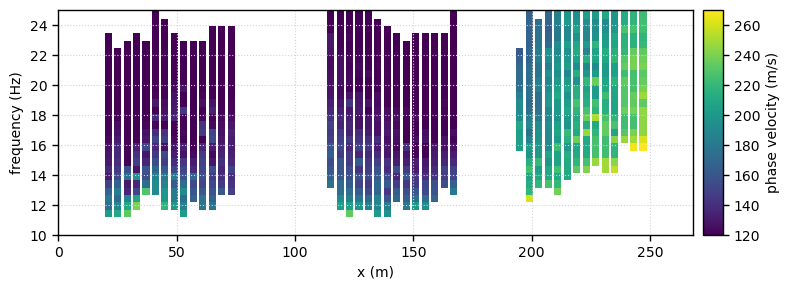

In [27]:
# plot pseudosection
c_map = 'viridis'

fig,ax = plt.subplots(figsize=(8,3))
swam.plot('pseudosection', method = 'FK',
          cmap = c_map, axes = ax,
          vmin = 120, vmax = 270,
          fmin  = 10.0, fmax = 25,
          width=3
         )
fig.suptitle(f'min_offset = {min_offset}, max_offset = {max_offset}, method={tr_type}, wlen = {w_len}, wmove = {w_m}', fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f'{prj_dir}/proc/masw2D/04_figs/pseudo_masw2D_smooth.png', dpi=150)

In [30]:
# save DCs
swam.save(method = 'FK', # tr_type
          dc_mode = 0, apply_to = 'all', use_windows=True)

Save dispersion curves corresponding to (SIN,REP) = (43, 2) to "../data/real_data/proc/masw2D/03_proc/proc1_FK/Mode0" ..... 1.1 s


## Comparing raw and smoothed dispersion curves

Here's the pseudosection after picking  
<img src="../../data/real_data/proc/masw2D/04_figs/pseudo_masw2D.png" width="800">

and this one after smoothing  
<img src="../../data/real_data/proc/masw2D/04_figs/pseudo_masw2D_smooth.png" width="800">